# House Recognition - Image Classification
Binary classification: predict whether an image is a **house (1)** or **not a house (0)**.

**Approach:** EfficientNet-B0 pretrained on ImageNet, fine-tuned on the provided training data.

In [1]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.6.0+cpu


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR   = r"c:\Users\punda\Desktop\superAI\Hackathon 5\Image processing\super-ai-engineer-season-6-individual-hackathon-house-recognition"
TRAIN_DIR  = os.path.join(BASE_DIR, "train", "train")
TEST_DIR   = os.path.join(BASE_DIR, "test",  "test")
TRAIN_CSV  = os.path.join(BASE_DIR, "train.csv")
SAMPLE_CSV = os.path.join(BASE_DIR, "sample_submission.csv")
SUBMIT_CSV = os.path.join(BASE_DIR, "submission.csv")

# ── Hyperparameters ────────────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 15
LR         = 1e-4
VAL_SPLIT  = 0.2

# ── Load training labels ───────────────────────────────────────────────────
train_df = pd.read_csv(TRAIN_CSV)
print(f"Train CSV shape: {train_df.shape}")
print(train_df["class"].value_counts())

Train CSV shape: (2953, 2)
class
0    1520
1    1433
Name: count, dtype: int64


In [3]:
# ── Image Transforms ───────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# ── Custom Dataset ─────────────────────────────────────────────────────────
class HouseDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_name"])
        image    = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = int(row["class"])
        return image, label


class TestDataset(Dataset):
    def __init__(self, img_ids, img_dir, transform=None):
        self.img_ids   = img_ids
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id   = self.img_ids[idx]
        img_path = os.path.join(self.img_dir, f"{img_id}.jpg")
        image    = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, img_id

print("Dataset classes defined.")

Dataset classes defined.


In [4]:
# ── Train / Validation Split ───────────────────────────────────────────────
from sklearn.model_selection import train_test_split

train_split, val_split = train_test_split(
    train_df, test_size=VAL_SPLIT, stratify=train_df["class"], random_state=SEED
)

train_dataset = HouseDataset(train_split, TRAIN_DIR, transform=train_transform)
val_dataset   = HouseDataset(val_split,   TRAIN_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

# ── Test DataLoader ────────────────────────────────────────────────────────
sample_df = pd.read_csv(SAMPLE_CSV)
test_ids  = sample_df["id"].tolist()

test_dataset = TestDataset(test_ids, TEST_DIR, transform=val_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f"Train samples : {len(train_dataset)}")
print(f"Val   samples : {len(val_dataset)}")
print(f"Test  samples : {len(test_dataset)}")

Train samples : 2362
Val   samples : 591
Test  samples : 1550


In [5]:
# ── Model: EfficientNet-B0 (pretrained) ────────────────────────────────────
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# Replace final classifier head for binary classification
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features, 1),
)
model = model.to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
print("Model ready.")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\punda/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:02<00:00, 9.32MB/s]

Trainable parameters: 4,008,829
Model ready.


In [6]:
# ── Training & Validation Functions ────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.float().unsqueeze(1).to(DEVICE)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds      = (torch.sigmoid(logits) >= 0.5).long()
        correct    += (preds == labels.long()).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.float().unsqueeze(1).to(DEVICE)

            logits = model(images)
            loss   = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)
            preds      = (torch.sigmoid(logits) >= 0.5).long()
            correct    += (preds == labels.long()).sum().item()
            total      += images.size(0)

    return total_loss / total, correct / total

print("Training functions defined.")

Training functions defined.


In [7]:
# ── Training Loop ──────────────────────────────────────────────────────────
best_val_acc  = 0.0
best_model_path = os.path.join(BASE_DIR, "best_model.pth")
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        saved = " ✓ saved"
    else:
        saved = ""

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}{saved}")

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")

Epoch 01/15 | Train Loss: 0.4400  Acc: 0.8196 | Val Loss: 0.2244  Acc: 0.9255 ✓ saved
Epoch 02/15 | Train Loss: 0.2095  Acc: 0.9166 | Val Loss: 0.1315  Acc: 0.9594 ✓ saved
Epoch 03/15 | Train Loss: 0.1587  Acc: 0.9386 | Val Loss: 0.1145  Acc: 0.9577
Epoch 04/15 | Train Loss: 0.1270  Acc: 0.9492 | Val Loss: 0.1103  Acc: 0.9577
Epoch 05/15 | Train Loss: 0.0875  Acc: 0.9699 | Val Loss: 0.1162  Acc: 0.9560
Epoch 06/15 | Train Loss: 0.0711  Acc: 0.9733 | Val Loss: 0.1235  Acc: 0.9543
Epoch 07/15 | Train Loss: 0.0454  Acc: 0.9843 | Val Loss: 0.1246  Acc: 0.9594
Epoch 08/15 | Train Loss: 0.0469  Acc: 0.9835 | Val Loss: 0.1244  Acc: 0.9628 ✓ saved
Epoch 09/15 | Train Loss: 0.0450  Acc: 0.9856 | Val Loss: 0.1226  Acc: 0.9560
Epoch 10/15 | Train Loss: 0.0421  Acc: 0.9860 | Val Loss: 0.1195  Acc: 0.9611
Epoch 11/15 | Train Loss: 0.0288  Acc: 0.9911 | Val Loss: 0.1263  Acc: 0.9594
Epoch 12/15 | Train Loss: 0.0296  Acc: 0.9907 | Val Loss: 0.1269  Acc: 0.9645 ✓ saved
Epoch 13/15 | Train Loss: 0.0359

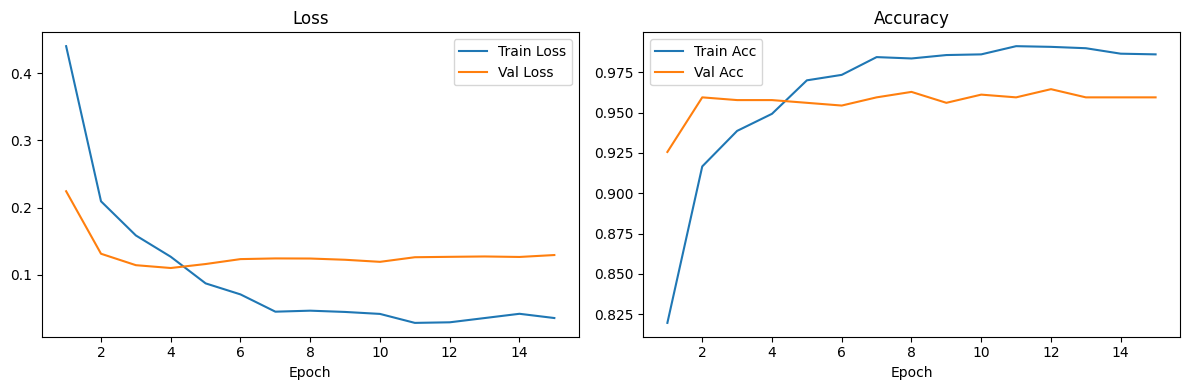

In [8]:
# ── Plot Training History ──────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"],   label="Val Acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "training_history.png"), dpi=100)
plt.show()

In [9]:
# ── Load Best Model & Predict on Test Set ─────────────────────────────────
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

all_ids   = []
all_preds = []

with torch.no_grad():
    for images, img_ids in test_loader:
        images = images.to(DEVICE)
        logits = model(images)
        preds  = (torch.sigmoid(logits) >= 0.5).long().squeeze(1).cpu().tolist()
        all_ids.extend(img_ids)
        all_preds.extend(preds)

print(f"Predicted {len(all_preds)} test images.")
print(f"House (1): {sum(all_preds)}  |  Not House (0): {len(all_preds) - sum(all_preds)}")

Predicted 1550 test images.
House (1): 753  |  Not House (0): 797


In [10]:
# ── Save Submission CSV ────────────────────────────────────────────────────
submission = pd.DataFrame({"id": all_ids, "answer": all_preds})

# Ensure IDs are in the same order as sample_submission.csv
submission = sample_df[["id"]].merge(submission, on="id", how="left")
submission["answer"] = submission["answer"].fillna(0).astype(int)

submission.to_csv(SUBMIT_CSV, index=False)
print(f"Submission saved to: {SUBMIT_CSV}")
print(submission.head(10))
print(f"\nTotal rows: {len(submission)}")

Submission saved to: c:\Users\punda\Desktop\superAI\Hackathon 5\Image processing\super-ai-engineer-season-6-individual-hackathon-house-recognition\submission.csv
         id  answer
0  e4b420b0       0
1  23efa479       0
2  1f0f2402       0
3  8a60480c       0
4  11f20127       0
5  16173ced       0
6  9c05fea1       0
7  11f04229       0
8  c055fbb7       0
9  ec045077       0

Total rows: 1550
